# Master-equation-based simulation

We present here the derivation of our Master-equation-based simulation.

Let the qutrit's density of state be $\rho_S$. It is being coupled to a bath. The time-evolution of the qutrit reads

\begin{align}
\frac{d\rho_S}{dt} = \frac{1}{i\hbar}\left[H'_{q}(t),\rho_S\right]+\sum_{\alpha}\left({L}_\alpha\rho_S L^\dagger_\alpha-\frac{1}{2}\rho_SL^\dagger_\alpha L_\alpha-\frac{1}{2}L_\alpha^\dagger L_\alpha \rho_S\right),
\end{align}

where we have used the RWA-approximated Hamiltonian,

\begin{align}
H_\text{q}'(t)/\hbar=&\delta\hat{b}^\dagger\hat{b}-\frac{\Delta}{2}\hat{b}^\dagger\hat{b}^\dagger\hat{b}\hat{b}\notag\\&+\Omega_d(t)e^{-i\phi_d}\hat b^\dagger+\Omega^*_d(t)e^{i\phi_d}\hat{b}
\end{align}

We now give more details on the Linblad operators $L_\alpha$. Our model takes into accounts the following decoherence source

\begin{align}
L_-^{(01)} = \sqrt{\Gamma_1^{(01)}}|0\rangle\langle 1|,\\
L_-^{(12)} = \sqrt{\Gamma_1^{(12)}}|1\rangle\langle 2|,\\
L_z^{(01)} = \sqrt{\Gamma_2^{(01)}}(|1\rangle\langle 1|-|0\rangle\langle 0|),\\
L_z^{(12)} = \sqrt{\Gamma_2^{(12)}}(|2\rangle\langle 2|-|1\rangle\langle 1|).
\end{align}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%config InlineBackend.figure_formats = ['png']
plt.rcParams.update({
    "font.family": "Helvetica"
})

%matplotlib inline
plt.rcParams['figure.dpi'] = 300

### Find $T_1^{(01)}, T_1^{(12)}$ through relaxation experiments

In [2]:
t1_measurement_data = np.load('./data/t1_measurement/data_main.npz')

t1_measurement_data

NpzFile './data/t1_measurement/data_main.npz' with keys: delay_time_mu, pop0, pop1, pop2

In [3]:
# Define model functions for populations
def p2_model(t, gamma21):
    return np.exp(-gamma21 * t)

def p1_model(t, gamma21, gamma10):
    return (gamma21 / (gamma10 - gamma21)) * (np.exp(-gamma21 * t) - np.exp(-gamma10 * t))

def p0_model(t, gamma21, gamma10):
    return 1 - p1_model(t, gamma21, gamma10) - p2_model(t, gamma21)

# Main fitting function for all populations at once
def populations_model(t, gamma21, gamma10):
    return np.concatenate([
        p0_model(t, gamma21, gamma10),
        p1_model(t, gamma21, gamma10),
        p2_model(t, gamma21)
    ])

def fit_qutrit_decay(delay_time_mu, pop0, pop1, pop2):
    # Convert µs → s if needed (here we keep µs units)
    t = np.array(delay_time_mu)

    # Flatten experimental data for simultaneous fitting
    ydata = np.concatenate([pop0, pop1, pop2])

    # Initial guess for rates
    guess = [0.1, 0.05]  # in 1/µs

    # Fit
    popt, pcov = curve_fit(
        populations_model, t, ydata, p0=guess, bounds=(0, np.inf)
    )
    gamma21, gamma10 = popt
    return gamma21, gamma10, pcov

Decay rate Γ21 = 0.0070 1/µs (T21 = 142.70 µs)
Decay rate Γ10 = 0.0067 1/µs (T10 = 148.77 µs)


C:\Users\tng-admin\AppData\Local\Temp\ipykernel_2184\982663601.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


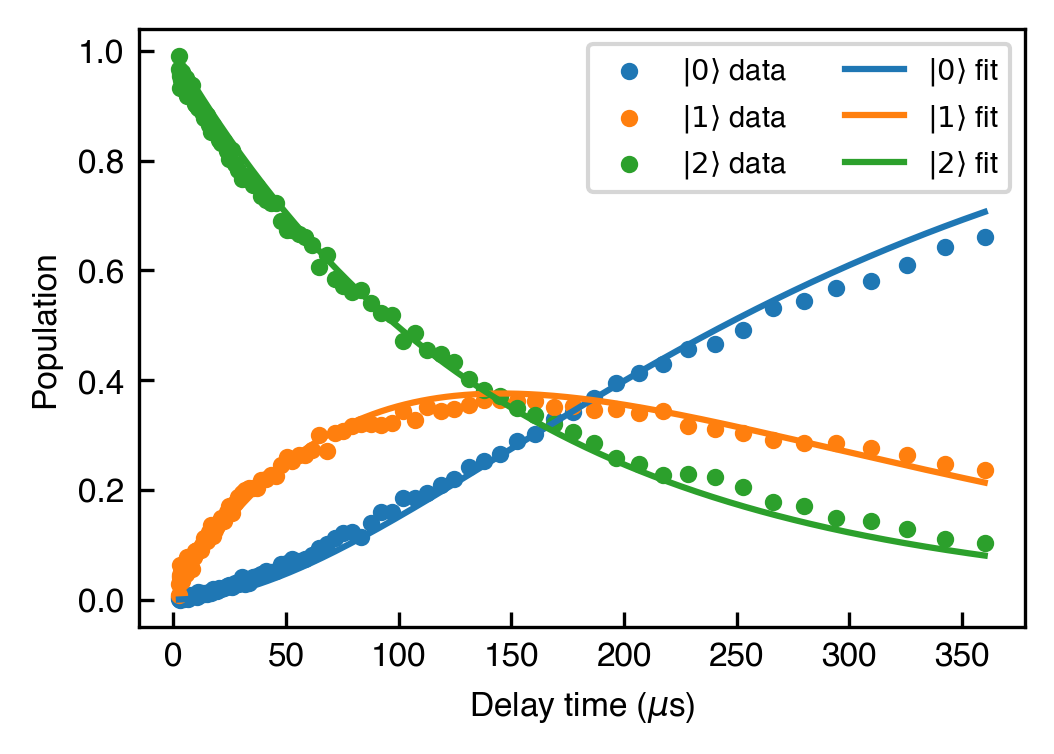

In [ ]:
delay_time_mu = t1_measurement_data['delay_time_mu']
pop0_t1_012 = t1_measurement_data['pop0']
pop1_t1_012 = t1_measurement_data['pop1']
pop2_t1_012 = t1_measurement_data['pop2']

gamma21, gamma10, pcov = fit_qutrit_decay(delay_time_mu, pop0_t1_012, pop1_t1_012, pop2_t1_012)

print(f"Decay rate Γ21 = {gamma21:.4f} 1/µs (T21 = {1/gamma21:.2f} µs)")
print(f"Decay rate Γ10 = {gamma10:.4f} 1/µs (T10 = {1/gamma10:.2f} µs)")

t_fit = np.linspace(min(delay_time_mu), max(delay_time_mu), 300)

fig, ax = plt.subplots(figsize=(3.4, 2.4), layout='constrained')

ax.scatter(delay_time_mu, pop0_t1_012, label=r"$|0\rangle$ data", s=10)
ax.scatter(delay_time_mu, pop1_t1_012, label=r"$|1\rangle$ data", s=10)
ax.scatter(delay_time_mu, pop2_t1_012, label=r"$|2\rangle$ data", s=10) 
ax.plot(t_fit, p0_model(t_fit, gamma21, gamma10), label=r"$|0\rangle$ fit")
ax.plot(t_fit, p1_model(t_fit, gamma21, gamma10), label=r"$|1\rangle$ fit")
ax.plot(t_fit, p2_model(t_fit, gamma21), label=r"$|2\rangle$ fit")
ax.set_xlabel(r"Delay time ($\mu$s)", fontsize=8)
ax.set_ylabel(r"Population", fontsize=8)

ax.legend(fontsize=7, frameon=True, ncols=2)
ax.tick_params(axis='both', which='both', direction='in', labelsize=8)
fig.savefig('./figures/appendix/t1_fit.pdf', bbox_inches=0)
fig.show()

### Find $T_2^{(01)}, T_2^{(12)}$ through Ramsey experiments

In [5]:
t2_measurement_data_r1 = np.load('./data/ramsey_measurement/round1.pkl', allow_pickle=True)
t2_measurement_data_r2 = np.load('./data/ramsey_measurement/round2.pkl', allow_pickle=True)
t2_measurement_data_r3 = np.load('./data/ramsey_measurement/round3.pkl', allow_pickle=True)

In [6]:
def iq_to_prob(IQdata_round):
    # Define mapping
    IQ_min, IQ_max = min(IQdata_round), max(IQdata_round)
    # Linear scaling to [0, 1]
    p1 = (IQdata_round - IQ_min) / (IQ_max - IQ_min)
    return p1

In [7]:
delay_time_ramsey = np.arange(8, 2000, 8) * 5e-10 / 1e-6
pop2_r1 = iq_to_prob(np.array(t2_measurement_data_r1))

delay_time_ramsey = np.arange(8, 2000, 8) * 5e-10 / 1e-6
pop2_r2 = iq_to_prob(np.array(t2_measurement_data_r2))

delay_time_ramsey_r3 = np.arange(48, 4800, 48) * 5e-10 / 1e-6
pop2_r3 = iq_to_prob(np.array(t2_measurement_data_r3))

In [11]:
# Ramsey model with two frequency components
def ramsey_two_freq(t, f1, f2, A1, A2, phi1, phi2):
    oscill = A1 * np.cos(2 * np.pi * f1 * t + phi1) + A2 * np.cos(2 * np.pi * f2 * t + phi2)
    return 1 * oscill + 0.5

def ramsey_three_freq(t, f1, f2, f3, A1, A2, phi1, phi2, phi3):
    oscill = A1 * np.cos(2 * np.pi * f1 * t + phi1) + A2 * np.cos(2 * np.pi * f2 * t + phi2) + (1-A1-A2) * np.cos(2 * np.pi * f3 * t + phi3) + 0.5
    return 1 * oscill

def fit_ramsey_two_freq(delay_time_mu, p1_array):
    t = np.array(delay_time_mu)
    y = np.array(p1_array)

    # Initial guesses
    # T2_guess = max(t) / 2
    f1_guess, f2_guess = 2, 3
    A1_guess, A2_guess = 0.5, 0.5
    phi1_guess, phi2_guess = 0.0, 0.0

    # Fit model
    popt, pcov = curve_fit(
        ramsey_two_freq, t, y,
        p0=[f1_guess, f2_guess, A1_guess, A2_guess, phi1_guess, phi2_guess],
        bounds=([0, 0, 0, 0, -np.pi, -np.pi], [np.inf, np.inf, 1, 1, np.pi, np.pi])
    )
    # Return results
    
    return popt, pcov

def fit_ramsey_three_freq(delay_time_mu, p1_array):
    t = np.array(delay_time_mu)
    y = np.array(p1_array)

    # Initial guesses
    f1_guess, f2_guess, f3_guess = 10, 11, 22.3
    A1_guess, A2_guess = 0.8, 0.9
    phi1_guess, phi2_guess, phi3_guess = 0.0, 0.0, 0.0

    # Fit model
    popt, pcov = curve_fit(
        ramsey_three_freq, t, y,
        p0=[f1_guess, f2_guess, f3_guess, A1_guess, A2_guess, phi1_guess, phi2_guess, phi3_guess],
        bounds=([0, 0, 0, 0, 0, -np.pi, -np.pi, -np.pi], [np.inf, np.inf, np.inf, 1, 1, np.pi, np.pi, np.pi])
    )
    # Return results
    
    return popt, pcov

In [9]:
popt_r1, pcov_r1 = fit_ramsey_three_freq(delay_time_ramsey, pop2_r1)

f1_r1, f2_r1, f3_r1, A1_r1, A2_r1, phi1_r1, phi2_r1, phi3_r1 = popt_r1

pop2_fit_r1 = ramsey_three_freq(delay_time_ramsey, f1_r1, f2_r1, f3_r1, A1_r1, A2_r1, phi1_r1, phi2_r1, phi3_r1)

print(f1_r1, f2_r1, f3_r1)

3.435435931030753 3.7733953682947075 8.021144452581742


In [12]:
popt_r2, pcov_r2 = fit_ramsey_three_freq(delay_time_ramsey, pop2_r2)

f1_r2, f2_r2, f3_r2, A1_r2, A2_r2, phi1_r2, phi2_r2, phi3_r2 = popt_r2

pop2_fit_r2 = ramsey_three_freq(delay_time_ramsey, f1_r2, f2_r2, f3_r2, A1_r2, A2_r2, phi1_r2, phi2_r2, phi3_r2)

print(f1_r2, f2_r2, f3_r2)

10.486158340026217 10.696720335647196 21.879475952985256


In [13]:
popt_r3, pcov_r3 = fit_ramsey_two_freq(delay_time_ramsey_r3, pop2_r3)

f1_r3, f2_r3, A1_r3, A2_r3, phi1_r3, phi2_r3 = popt_r3

pop2_fit_r3 = ramsey_two_freq(delay_time_ramsey_r3, f1_r3, f2_r3, A1_r3, A2_r3, phi1_r3, phi2_r3)

print(f1_r3, f2_r3)

2.158546681184758 3.0310530970955782


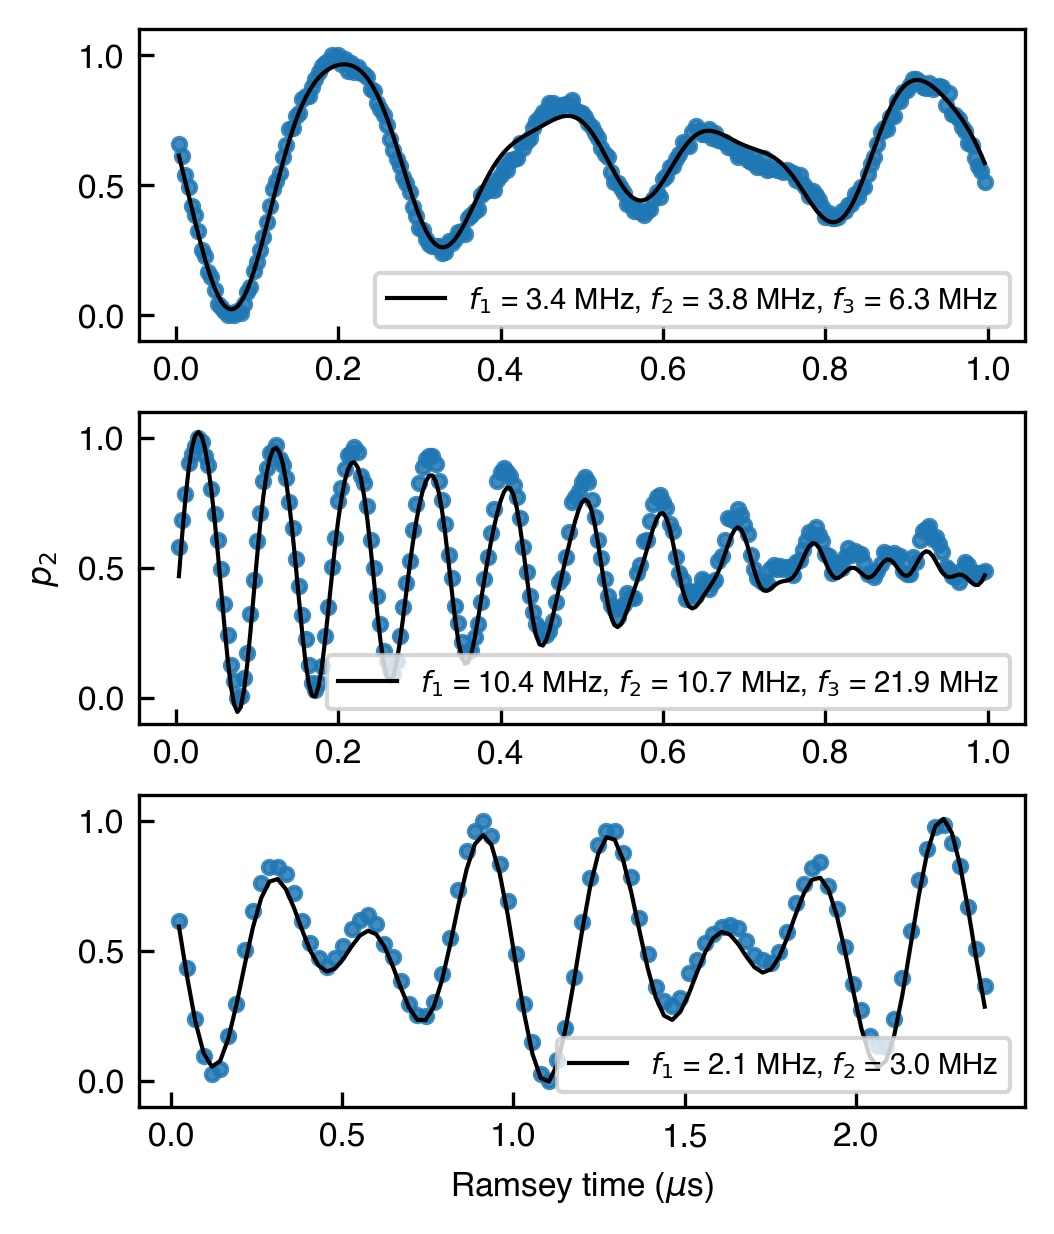

In [15]:
fig, axes = plt.subplots(figsize=(3.4, 4), layout='constrained', nrows=3)

axes[0].plot(delay_time_ramsey, pop2_fit_r1+0.1, color='black', lw=1, label=r'$f_1$ = 3.4 MHz, $f_2$ = 3.8 MHz, $f_3$ = 6.3 MHz')
axes[0].scatter(delay_time_ramsey, pop2_r1, color='tab:blue', s=10, alpha=0.85)

axes[1].plot(delay_time_ramsey, pop2_fit_r2, color='black', lw=1, label=r'$f_1$ = 10.4 MHz, $f_2$ = 10.7 MHz, $f_3$ = 21.9 MHz')
axes[1].scatter(delay_time_ramsey, pop2_r2, color='tab:blue', s=10, alpha=0.85)

axes[2].plot(delay_time_ramsey_r3, pop2_fit_r3, color='black', lw=1, label=r'$f_1$ = 2.1 MHz, $f_2$ = 3.0 MHz')
axes[2].scatter(delay_time_ramsey_r3, pop2_r3, color='tab:blue', s=10, alpha=0.85)

for ax in axes: 
    ax.set_yticks((0, 0.5, 1))
    ax.set_ylim(-0.1, 1.1)
    # ax.set_xlim(0, 1)
    ax.legend(fontsize=7, frameon=True)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=8)

axes[1].set_ylabel(r'$p_2$', fontsize=8)
axes[2].set_xlabel(r'Ramsey time ($\mu$s)', fontsize=8)

# fig.text(0.00, 0.99, '(c)', va='center', fontsize=8)
fig.savefig('./figures/appendix/ramsey.pdf', bbox_inches=0)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(delay_time_ramsey, pop2_fit+0.1, color='black', lw=2, label=r'$f_1$=3.4 MHz, $f_2$=3.8 MHz, $f_3$=8 MHz')
ax.scatter(delay_time_ramsey, pop2, color='tab:blue', s=20, alpha=0.85)
ax.set_yticks((0, 0.5, 1))
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(0, 1)
ax.legend(fontsize=15, frameon=True)
ax.set_ylabel(r'$p_2$', fontsize=15, labelpad=3)
ax.set_xlabel(r'Ramsey time ($\mu$s)', fontsize=15, labelpad=0)
ax.tick_params(axis='both', which='major', top=True, right=True,
                length=7, width=1.5, direction='in', labelsize=15)
ax.tick_params(axis='both', which='minor', top=True, right=True,
                length=3, width=1.5, direction='in')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

fig.text(0.00, 0.99, '(c)', va='center', fontsize=15)

fig.tight_layout()
# fig.savefig('fig1b_ramseyfit.svg', bbox_inches='tight')

Note for 01, we're taking the value reported by IBMQ

In [11]:
T2_01 = 183.21*1e-6

print(f'T2_01 = {T2_01/1e-6} µs')

T2_01 = 183.21 µs


### Conclusion

We convert all the timescales to `ns` since we're simulating with GHz scale

In [23]:
T_10_decay_ns = 148.77*1e-6/1e-9
T_20_decay_ns = 142.70*1e-6/1e-9

T_10_dephasing_ns = T2_01/1e-9
T_20_dephasing_ns = T2star_12*1e-6/1e-9

print(T_10_decay_ns)
print(T_20_decay_ns)
print(T_10_dephasing_ns)
print(T_20_dephasing_ns)

148770.0
142699.99999999997
183210.0
107548.6134366413


In [9]:
print('Decay rate 1->0: ',gamma10)
print('Decay rate 2->1: ',gamma21)

Decay rate 1->0:  0.0067217104369748076
Decay rate 2->1:  0.007007777226070338


In [13]:
print('Dephasing rate 01:', dephasing01_rate)

Dephasing rate 01: 5458.217346214727
